# vLLM Inference Lab: what the optimizations actually buy you

Hands-on experiments with the ideas behind fast LLM serving, run on one Colab L4 GPU:

1. **Continuous batching:** vLLM vs. plain Hugging Face `generate()`, as load goes up
2. **PagedAttention and the KV cache:** how much fits in GPU memory, and what prefix caching does for agent-style prompts
3. **Speculative decoding:** n-gram speculation at low vs. high load
4. **Quantization:** FP16 vs. FP8

Each experiment measures something real (throughput, time to first token, latency, KV cache capacity) instead of just describing the idea.

**Before you start:** Runtime → Change runtime type → **L4 GPU**.

## 0. Setup

In [1]:
# Confirm we're on a GPU (should say L4)
!nvidia-smi --query-gpu=name,memory.total --format=csv
!pip uninstall -y torchaudio

name, memory.total [MiB]
NVIDIA L4, 23034 MiB
Found existing installation: torchaudio 2.11.0
Uninstalling torchaudio-2.11.0:
  Successfully uninstalled torchaudio-2.11.0


In [2]:
# Install vLLM. This replaces Colab's preinstalled PyTorch with the version vLLM needs.
# Takes a few minutes.
!pip install -q vllm openai matplotlib pandas nest_asyncio

# Colab's preinstalled torchaudio was built for a different CUDA version than the PyTorch vLLM
# just installed. transformers imports torchaudio if it's present and crashes on the mismatch,
# so remove it. Nothing in this lab uses audio.
!pip uninstall -y -q torchaudio

In [ ]:
# Restart the runtime so the new PyTorch gets loaded.
# Colab will show a "session crashed" message. That's expected: just continue with the next cell.
import os
os.kill(os.getpid(), 9)

## 1. Helpers

Everything below uses these: start and stop a vLLM server in the background, send it load, and measure.

In [1]:
import asyncio, json, os, re, signal, subprocess, time
import statistics as st

import matplotlib.pyplot as plt
import pandas as pd
import requests
from openai import AsyncOpenAI

# A small, ungated model so every experiment runs in minutes. No Hugging Face token needed.
MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
PORT = 8000
BASE_URL = f"http://localhost:{PORT}/v1"
LOG = "/content/vllm_server.log"

_server = None


def start_server(*extra_args, timeout=900):
    """Start `vllm serve` in the background with the given flags, and wait until it's ready."""
    global _server
    stop_server()
    cmd = ["vllm", "serve", MODEL, "--port", str(PORT), *extra_args]
    print("Starting:", " ".join(cmd))
    log = open(LOG, "w")
    # start_new_session lets us kill the server and all its worker processes together
    _server = subprocess.Popen(cmd, stdout=log, stderr=subprocess.STDOUT, start_new_session=True)
    start = time.time()
    while time.time() - start < timeout:
        if _server.poll() is not None:  # the server process died
            print(open(LOG).read()[-3000:])
            raise RuntimeError("vLLM server exited during startup. See the log above.")
        try:
            if requests.get(f"http://localhost:{PORT}/health", timeout=2).status_code == 200:
                print(f"Ready in {time.time() - start:.0f}s")
                return
        except requests.exceptions.ConnectionError:
            pass
        time.sleep(3)
    raise TimeoutError("vLLM server didn't become ready in time. Check " + LOG)


def stop_server():
    """Stop the running server (if any) and free the GPU for the next experiment."""
    global _server
    if _server and _server.poll() is None:
        os.killpg(os.getpgid(_server.pid), signal.SIGTERM)
        try:
            _server.wait(timeout=60)
        except subprocess.TimeoutExpired:
            os.killpg(os.getpgid(_server.pid), signal.SIGKILL)
    _server = None
    time.sleep(5)  # give the GPU memory a moment to be released


def kv_cache_info():
    """Pull the KV cache lines out of the server log (how many tokens fit, max concurrency)."""
    lines = open(LOG).read().splitlines()
    return [l.split("] ")[-1] for l in lines if re.search(r"KV cache|[Cc]oncurrency|GPU blocks", l)]


async def _one_request(client, messages, max_tokens, extra):
    """Send one streaming request. Returns time to first token, total latency, and output tokens."""
    start = time.perf_counter()
    ttft, tokens = None, 0
    stream = await client.chat.completions.create(
        model=MODEL, messages=messages, max_tokens=max_tokens, temperature=0,
        stream=True, stream_options={"include_usage": True}, extra_body=extra,
    )
    async for chunk in stream:
        if ttft is None and chunk.choices and chunk.choices[0].delta.content:
            ttft = time.perf_counter() - start
        if chunk.usage:
            tokens = chunk.usage.completion_tokens
    return ttft or 0.0, time.perf_counter() - start, tokens


async def _run(prompts, concurrency, max_tokens, extra):
    client = AsyncOpenAI(base_url=BASE_URL, api_key="none")
    sem = asyncio.Semaphore(concurrency)  # never more than `concurrency` requests in flight

    async def limited(messages):
        async with sem:
            return await _one_request(client, messages, max_tokens, extra)

    start = time.perf_counter()
    results = await asyncio.gather(*(limited(p) for p in prompts))
    return results, time.perf_counter() - start


def run_load(prompts, concurrency, max_tokens=200, fixed_length=True):
    """Send all prompts with up to `concurrency` in flight at once, and summarize the results.

    fixed_length=True makes every request generate exactly max_tokens (ignore_eos), so runs
    are directly comparable. Turn it off when the actual output matters (speculative decoding).
    """
    extra = {"ignore_eos": True} if fixed_length else {}
    results, wall = asyncio.run(_run(prompts, concurrency, max_tokens, extra))
    ttfts = [r[0] for r in results]
    lat = [r[1] for r in results]
    toks = sum(r[2] for r in results)
    return {
        "concurrency": concurrency,
        "requests": len(prompts),
        "output_tok_per_s": round(toks / wall, 1),
        "ttft_p50_ms": round(st.median(ttfts) * 1000),
        "ttft_p95_ms": round(sorted(ttfts)[int(0.95 * (len(ttfts) - 1))] * 1000),
        "latency_p50_s": round(st.median(lat), 2),
    }


# Colab already runs an event loop, so allow asyncio.run() inside it
import nest_asyncio
nest_asyncio.apply()

In [2]:
# Quick check that the install worked
import vllm, torch
print("vLLM", vllm.__version__, "| torch", torch.__version__, "| GPU:", torch.cuda.get_device_name(0))

vLLM 0.30.0 | torch 2.13.0+cu130 | GPU: NVIDIA L4


In [3]:
# Workloads

# Short, varied chat questions (the generic case)
QUESTIONS = [
    "Explain what a database connection pool is.",
    "What causes high p99 latency in a web service?",
    "How does a Kubernetes liveness probe work?",
    "What is the difference between TCP and UDP?",
    "Why would a deploy cause a spike in error rate?",
    "What does a load balancer do?",
    "Explain exponential backoff for retries.",
    "What is a memory leak and how do you find one?",
]
def chat_prompts(n):
    return [[{"role": "user", "content": QUESTIONS[i % len(QUESTIONS)]}] for i in range(n)]

# Agent-style prompts: the SAME long system prompt (instructions + tool definitions) on every
# request, with a short question at the end. This is what an agent sends on every step.
TOOLS = "\n".join(
    f"- tool_{i}(service: str, window: str) -> str: Returns metric group {i} for the service "
    f"over the given window, including p50, p95, p99 latency, error rate, saturation, and notes."
    for i in range(60)
)
AGENT_SYSTEM = (
    "You are an on-call SRE agent. Investigate alerts step by step, call tools when needed, "
    "and explain your reasoning. Available tools:\n" + TOOLS
)
def agent_prompts(n):
    return [
        [{"role": "system", "content": AGENT_SYSTEM},
         {"role": "user", "content": f"Alert {i}: {QUESTIONS[i % len(QUESTIONS)]} Which tool first?"}]
        for i in range(n)
    ]

results = {}  # everything we measure ends up here
print("System prompt length (chars):", len(AGENT_SYSTEM))

System prompt length (chars): 10671


## 2. Continuous batching

**The idea:** a naive server waits for a whole batch to finish before starting the next one, so short requests sit idle behind long ones. vLLM schedules at the token level: as soon as any request finishes, a waiting one takes its slot.

**The test:** first, plain Hugging Face `generate()` with static batches as a baseline. Then vLLM at increasing concurrency.

In [6]:
# Baseline: Hugging Face transformers with static batching (no vLLM server running yet).
#
# This runs in a separate Python process on purpose. When that process exits, all of its GPU
# memory is released. If we ran it here in the notebook, the notebook would keep ~3 GB of GPU
# memory reserved, and vLLM would refuse to start because it expects ~92% of the GPU to be free.
BASELINE = r'''
import json, time, torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL, QUESTIONS = json.loads(open("/content/baseline_args.json").read())
tok = AutoTokenizer.from_pretrained(MODEL, padding_side="left")
model = AutoModelForCausalLM.from_pretrained(MODEL, dtype=torch.float16, device_map="cuda")

rows = []
for batch_size in (1, 8, 32):
    prompts = [[{"role": "user", "content": QUESTIONS[i % len(QUESTIONS)]}] for i in range(batch_size)]
    texts = [tok.apply_chat_template(p, tokenize=False, add_generation_prompt=True) for p in prompts]
    inputs = tok(texts, return_tensors="pt", padding=True).to("cuda")
    torch.cuda.synchronize(); start = time.perf_counter()
    # min_new_tokens forces every sequence to 200 tokens, same as ignore_eos on the vLLM side
    out = model.generate(**inputs, max_new_tokens=200, min_new_tokens=200, do_sample=False)
    torch.cuda.synchronize(); wall = time.perf_counter() - start
    new_tokens = (out.shape[1] - inputs["input_ids"].shape[1]) * batch_size
    rows.append({"engine": "HF generate (static batch)", "concurrency": batch_size,
                 "output_tok_per_s": round(new_tokens / wall, 1)})
    print(rows[-1], flush=True)
json.dump(rows, open("/content/baseline_results.json", "w"))
'''
open("/content/baseline.py", "w").write(BASELINE)
json.dump([MODEL, QUESTIONS], open("/content/baseline_args.json", "w"))
!python /content/baseline.py
hf_rows = json.load(open("/content/baseline_results.json"))

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

{'engine': 'HF generate (static batch)', 'concurrency': 1, 'output_tok_per_s': 19.3}
{'engine': 'HF generate (static batch)', 'concurrency': 8, 'output_tok_per_s': 189.8}
{'engine': 'HF generate (static batch)', 'concurrency': 32, 'output_tok_per_s': 736.5}


In [5]:
start_server()  # default settings
print("\n".join(kv_cache_info()))

vllm_rows = []
for c in (1, 8, 32, 64):
    r = run_load(chat_prompts(max(2 * c, 8)), concurrency=c)
    vllm_rows.append({"engine": "vLLM (continuous batching)", **r})
    print(vllm_rows[-1])

results["continuous_batching"] = pd.DataFrame(hf_rows + vllm_rows)
results["continuous_batching"]

Starting: vllm serve Qwen/Qwen2.5-1.5B-Instruct --port 8000
Ready in 192s
Using LBNHC KV cache layout.
Available KV cache memory: 15.8 GiB
CUDA graph memory profiling is enabled (default since v0.21.0). The current --gpu-memory-utilization=0.9200 is equivalent to --gpu-memory-utilization=0.9041 without CUDA graph memory profiling. To maintain the same effective KV cache size as before, increase --gpu-memory-utilization to 0.9359. To disable, set VLLM_MEMORY_PROFILER_ESTIMATE_CUDAGRAPHS=0.
GPU KV cache size: 591,872 tokens, Maximum concurrency for 32,768 tokens per request: 18.06x
{'engine': 'vLLM (continuous batching)', 'concurrency': 1, 'requests': 8, 'output_tok_per_s': 68.9, 'ttft_p50_ms': 25, 'ttft_p95_ms': 26, 'latency_p50_s': 2.7}
{'engine': 'vLLM (continuous batching)', 'concurrency': 8, 'requests': 16, 'output_tok_per_s': 574.1, 'ttft_p50_ms': 57, 'ttft_p95_ms': 67, 'latency_p50_s': 2.78}
{'engine': 'vLLM (continuous batching)', 'concurrency': 32, 'requests': 64, 'output_tok_pe

,engine,concurrency,output_tok_per_s,requests,ttft_p50_ms,ttft_p95_ms,latency_p50_s
0,HF generate (static batch),1,19.3,NaN,NaN,NaN,NaN
1,HF generate (static batch),8,189.8,NaN,NaN,NaN,NaN
2,HF generate (static batch),32,736.5,NaN,NaN,NaN,NaN
3,vLLM (continuous batching),1,68.9,8.0,25.0,26.0,2.70
4,vLLM (continuous batching),8,574.1,16.0,57.0,67.0,2.78
5,vLLM (continuous batching),32,1979.1,64.0,131.0,153.0,3.22
6,vLLM (continuous batching),64,3483.6,128.0,212.0,271.0,3.64


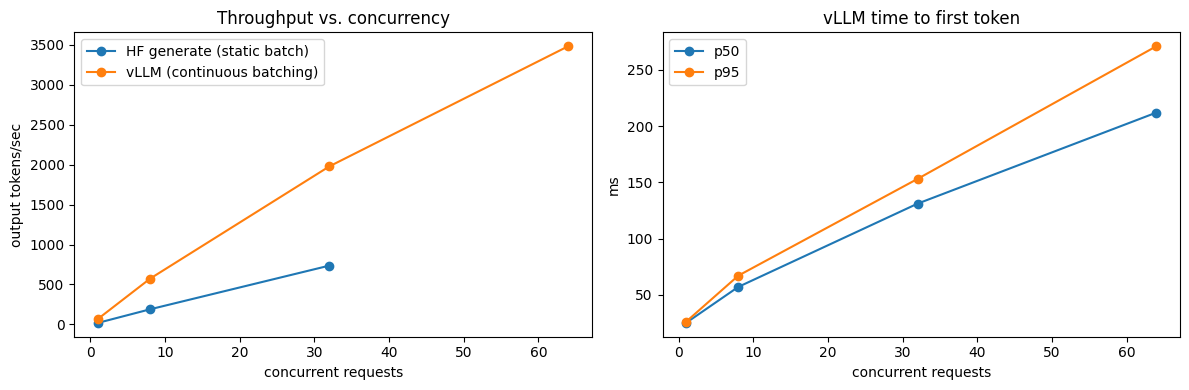

In [6]:
df = results["continuous_batching"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for engine, g in df.groupby("engine"):
    ax[0].plot(g["concurrency"], g["output_tok_per_s"], marker="o", label=engine)
ax[0].set(title="Throughput vs. concurrency", xlabel="concurrent requests", ylabel="output tokens/sec")
ax[0].legend()
v = df[df["engine"].str.startswith("vLLM")]
ax[1].plot(v["concurrency"], v["ttft_p50_ms"], marker="o", label="p50")
ax[1].plot(v["concurrency"], v["ttft_p95_ms"], marker="o", label="p95")
ax[1].set(title="vLLM time to first token", xlabel="concurrent requests", ylabel="ms")
ax[1].legend(); plt.tight_layout(); plt.show()

**What to look for:** vLLM throughput should keep climbing with concurrency while time to first token rises only gradually. That's the point: the GPU does far more total work when many requests share it.

## 3. PagedAttention and the KV cache

**The idea:** every token being generated needs the keys and values of all previous tokens (the KV cache). Old servers reserved one big contiguous chunk per request, sized for the longest possible output, and wasted most of it. PagedAttention stores the cache in small fixed-size blocks, like pages in virtual memory, allocated only as needed. More requests fit in the same GPU memory.

**Test 1:** how much KV cache capacity do different settings give us? (vLLM reports this at startup.)

In [7]:
kv_rows = []
for mem_util in (0.5, 0.9):
    for max_len in (2048, 8192):
        start_server("--gpu-memory-utilization", str(mem_util), "--max-model-len", str(max_len))
        info = kv_cache_info()
        kv_rows.append({"gpu_memory_utilization": mem_util, "max_model_len": max_len, "vllm_says": " | ".join(info)})
        print(kv_rows[-1])
results["kv_capacity"] = pd.DataFrame(kv_rows)
results["kv_capacity"]

Starting: vllm serve Qwen/Qwen2.5-1.5B-Instruct --port 8000 --gpu-memory-utilization 0.5 --max-model-len 2048
Ready in 84s
{'gpu_memory_utilization': 0.5, 'max_model_len': 2048, 'vllm_says': 'Using LBNHC KV cache layout. | Available KV cache memory: 6.55 GiB | CUDA graph memory profiling is enabled (default since v0.21.0). The current --gpu-memory-utilization=0.5000 is equivalent to --gpu-memory-utilization=0.4841 without CUDA graph memory profiling. To maintain the same effective KV cache size as before, increase --gpu-memory-utilization to 0.5159. To disable, set VLLM_MEMORY_PROFILER_ESTIMATE_CUDAGRAPHS=0. | GPU KV cache size: 245,296 tokens, Maximum concurrency for 2,048 tokens per request: 119.77x'}
Starting: vllm serve Qwen/Qwen2.5-1.5B-Instruct --port 8000 --gpu-memory-utilization 0.5 --max-model-len 8192
Ready in 84s
{'gpu_memory_utilization': 0.5, 'max_model_len': 8192, 'vllm_says': 'Using LBNHC KV cache layout. | Available KV cache memory: 6.55 GiB | CUDA graph memory profilin

,gpu_memory_utilization,max_model_len,vllm_says
0,0.5,2048,Using LBNHC KV cache layout. | Available KV ca...
1,0.5,8192,Using LBNHC KV cache layout. | Available KV ca...
2,0.9,2048,Using LBNHC KV cache layout. | Available KV ca...
3,0.9,8192,Using LBNHC KV cache layout. | Available KV ca...


**What to look for:** the total KV cache size in tokens depends on how much memory you give vLLM. The maximum concurrency depends on that *and* on how long each request is allowed to be. Longer allowed context means fewer requests fit at once, which is a real capacity-planning trade-off.

**Test 2: prefix caching for agent workloads.** Agents send the same long system prompt and tool list on every step. With prefix caching, vLLM keeps the KV cache for that shared prefix and reuses it instead of recomputing it for every request. We run the agent workload with prefix caching off and on.

In [8]:
prefix_rows = []
for label, flag in (("prefix caching OFF", "--no-enable-prefix-caching"), ("prefix caching ON", "--enable-prefix-caching")):
    start_server(flag)
    run_load(agent_prompts(4), concurrency=4, max_tokens=50)  # warm-up (fills the cache when it's on)
    r = run_load(agent_prompts(32), concurrency=8, max_tokens=50)
    prefix_rows.append({"setting": label, **r})
    print(prefix_rows[-1])
results["prefix_caching"] = pd.DataFrame(prefix_rows)
results["prefix_caching"]

Starting: vllm serve Qwen/Qwen2.5-1.5B-Instruct --port 8000 --no-enable-prefix-caching
Ready in 63s
{'setting': 'prefix caching OFF', 'concurrency': 8, 'requests': 32, 'output_tok_per_s': 167.1, 'ttft_p50_ms': 670, 'ttft_p95_ms': 1335, 'latency_p50_s': 2.37}
Starting: vllm serve Qwen/Qwen2.5-1.5B-Instruct --port 8000 --enable-prefix-caching
Ready in 63s
{'setting': 'prefix caching ON', 'concurrency': 8, 'requests': 32, 'output_tok_per_s': 496.0, 'ttft_p50_ms': 73, 'ttft_p95_ms': 108, 'latency_p50_s': 0.79}


,setting,concurrency,requests,output_tok_per_s,ttft_p50_ms,ttft_p95_ms,latency_p50_s
0,prefix caching OFF,8,32,167.1,670,1335,2.37
1,prefix caching ON,8,32,496.0,73,108,0.79


**What to look for:** time to first token should drop a lot with prefix caching on, because the long shared prefix doesn't get recomputed. For agents, which resend the same instructions and tools every step, this is one of the biggest wins available.

## 4. Speculative decoding

**The idea:** generating one token at a time leaves the GPU underused at low load. Speculative decoding guesses several tokens ahead cheaply, then has the real model check all the guesses in a single pass. Correct guesses are kept, so you get multiple tokens per step.

We use **n-gram speculation** (also called prompt lookup): it guesses by copying text that already appeared in the prompt. No second draft model needed. It works best when the output repeats the input, like editing code or rewriting a config, which is common in agent work.

**The test:** a "return this config with one change" task, with speculation off and on, at low and high load. Here we let the model finish naturally, since the actual output matters for speculation.

In [9]:
CONFIG = json.dumps({f"service_{i}": {"replicas": 3, "cpu": "500m", "memory": "512Mi",
                     "timeout_ms": 2000, "retries": 3} for i in range(12)}, indent=2)
def edit_prompts(n):
    return [[{"role": "user", "content": f"Return this JSON config exactly, but change service_{i % 12} "
              f"timeout_ms to 5000. Output only the JSON.\n\n{CONFIG}"}] for i in range(n)]

SPEC = json.dumps({"method": "ngram", "num_speculative_tokens": 4, "prompt_lookup_max": 4, "prompt_lookup_min": 2})

spec_rows = []
for label, args in (("speculation OFF", ()), ("speculation ON (n-gram)", ("--speculative-config", SPEC))):
    start_server(*args)
    for c in (1, 32):
        r = run_load(edit_prompts(max(2 * c, 8)), concurrency=c, max_tokens=700, fixed_length=False)
        spec_rows.append({"setting": label, **r})
        print(spec_rows[-1])
results["speculative"] = pd.DataFrame(spec_rows)
results["speculative"]

Starting: vllm serve Qwen/Qwen2.5-1.5B-Instruct --port 8000
Ready in 60s
{'setting': 'speculation OFF', 'concurrency': 1, 'requests': 8, 'output_tok_per_s': 74.1, 'ttft_p50_ms': 54, 'ttft_p95_ms': 55, 'latency_p50_s': 9.19}
{'setting': 'speculation OFF', 'concurrency': 32, 'requests': 64, 'output_tok_per_s': 1812.2, 'ttft_p50_ms': 152, 'ttft_p95_ms': 292, 'latency_p50_s': 11.99}
Starting: vllm serve Qwen/Qwen2.5-1.5B-Instruct --port 8000 --speculative-config {"method": "ngram", "num_speculative_tokens": 4, "prompt_lookup_max": 4, "prompt_lookup_min": 2}
Ready in 228s
{'setting': 'speculation ON (n-gram)', 'concurrency': 1, 'requests': 8, 'output_tok_per_s': 251.5, 'ttft_p50_ms': 47, 'ttft_p95_ms': 48, 'latency_p50_s': 2.48}
{'setting': 'speculation ON (n-gram)', 'concurrency': 32, 'requests': 64, 'output_tok_per_s': 3632.9, 'ttft_p50_ms': 149, 'ttft_p95_ms': 303, 'latency_p50_s': 5.96}


,setting,concurrency,requests,output_tok_per_s,ttft_p50_ms,ttft_p95_ms,latency_p50_s
0,speculation OFF,1,8,74.1,54,55,9.19
1,speculation OFF,32,64,1812.2,152,292,11.99
2,speculation ON (n-gram),1,8,251.5,47,48,2.48
3,speculation ON (n-gram),32,64,3632.9,149,303,5.96


**What I expected going in:** at concurrency 1, speculation should cut latency noticeably, since the GPU has spare capacity to check extra tokens. At concurrency 32, I expected the gain to shrink or even reverse, because a busy GPU wastes real work on rejected guesses. (It didn't reverse in this run. See "What I found" at the end.)

If the server fails to start here, the speculative config format may have changed in your vLLM version. Check the log and the vLLM docs for `--speculative-config`.

## 5. Quantization: FP16 vs. FP8

**The idea:** storing weights in 8 bits instead of 16 halves their memory. That leaves more room for the KV cache, and the L4 has hardware support for FP8 math.

**The test:** same load, both precisions. Compare KV cache capacity, throughput, and a quick look at output quality.

In [10]:
quant_rows, samples = [], {}
QUALITY_PROMPTS = [[{"role": "user", "content": q}] for q in QUESTIONS[:3]]

async def _answers(prompts):
    client = AsyncOpenAI(base_url=BASE_URL, api_key="none")
    rs = await asyncio.gather(*(client.chat.completions.create(model=MODEL, messages=p, max_tokens=120, temperature=0) for p in prompts))
    return [r.choices[0].message.content for r in rs]

for label, args in (("FP16", ()), ("FP8", ("--quantization", "fp8"))):
    start_server(*args)
    r = run_load(chat_prompts(64), concurrency=32)
    quant_rows.append({"precision": label, **r, "kv_cache": " | ".join(kv_cache_info())})
    samples[label] = asyncio.run(_answers(QUALITY_PROMPTS))
    print(quant_rows[-1])

results["quantization"] = pd.DataFrame(quant_rows)
display(results["quantization"])
for i, p in enumerate(QUALITY_PROMPTS):
    print("=" * 80, "\nQ:", p[0]["content"])
    for label in samples:
        print(f"\n[{label}] {samples[label][i][:400]}")

Starting: vllm serve Qwen/Qwen2.5-1.5B-Instruct --port 8000
Ready in 60s
{'precision': 'FP16', 'concurrency': 32, 'requests': 64, 'output_tok_per_s': 1987.1, 'ttft_p50_ms': 150, 'ttft_p95_ms': 213, 'latency_p50_s': 3.19, 'kv_cache': 'Using LBNHC KV cache layout. | Available KV cache memory: 16.54 GiB | CUDA graph memory profiling is enabled (default since v0.21.0). The current --gpu-memory-utilization=0.9200 is equivalent to --gpu-memory-utilization=0.9041 without CUDA graph memory profiling. To maintain the same effective KV cache size as before, increase --gpu-memory-utilization to 0.9359. To disable, set VLLM_MEMORY_PROFILER_ESTIMATE_CUDAGRAPHS=0. | GPU KV cache size: 619,376 tokens, Maximum concurrency for 32,768 tokens per request: 18.90x'}
Starting: vllm serve Qwen/Qwen2.5-1.5B-Instruct --port 8000 --quantization fp8
Ready in 108s
{'precision': 'FP8', 'concurrency': 32, 'requests': 64, 'output_tok_per_s': 2572.9, 'ttft_p50_ms': 350, 'ttft_p95_ms': 582, 'latency_p50_s': 2.47, 'kv_

,precision,concurrency,requests,output_tok_per_s,ttft_p50_ms,ttft_p95_ms,latency_p50_s,kv_cache
0,FP16,32,64,1987.1,150,213,3.19,Using LBNHC KV cache layout. | Available KV ca...
1,FP8,32,64,2572.9,350,582,2.47,Using LBNHC KV cache layout. | Available KV ca...


Q: Explain what a database connection pool is.

[FP16] A database connection pool is an object that manages the creation and reuse of database connections in a Java application. It acts as a buffer between the application code and the underlying database server.

Here's how it works:

1. When the application needs to connect to the database, it requests a connection from the connection pool.
2. The connection pool checks if there are any available con

[FP8] A database connection pool is an object that manages the creation and reuse of database connections in a Java application. It acts as a buffer between the application code and the actual database server.

Here's how it works:

1. When your application needs to connect to a database, it first checks if there is already a connection available in the pool.
2. If a connection is available, it uses tha
Q: What causes high p99 latency in a web service?

[FP16] High P99 latency can be caused by several factors in a web service:

1. **Netw

**What to look for:** FP8 should report a larger KV cache (more concurrent requests fit) and similar or better throughput, with answers that read about the same. On a model this small the throughput difference may be modest. Quantization matters most when memory is the bottleneck, with bigger models or longer contexts.

## 6. Wrap up

In [11]:
stop_server()

# Save every result table to CSV, so you can reuse the numbers in a blog post or README
os.makedirs("/content/results", exist_ok=True)
for name, df in results.items():
    df.to_csv(f"/content/results/{name}.csv", index=False)
    print(f"\n=== {name} ===")
    display(df)


=== continuous_batching ===


,engine,concurrency,output_tok_per_s,requests,ttft_p50_ms,ttft_p95_ms,latency_p50_s
0,HF generate (static batch),1,19.3,NaN,NaN,NaN,NaN
1,HF generate (static batch),8,189.8,NaN,NaN,NaN,NaN
2,HF generate (static batch),32,736.5,NaN,NaN,NaN,NaN
3,vLLM (continuous batching),1,68.9,8.0,25.0,26.0,2.70
4,vLLM (continuous batching),8,574.1,16.0,57.0,67.0,2.78
5,vLLM (continuous batching),32,1979.1,64.0,131.0,153.0,3.22
6,vLLM (continuous batching),64,3483.6,128.0,212.0,271.0,3.64



=== kv_capacity ===


,gpu_memory_utilization,max_model_len,vllm_says
0,0.5,2048,Using LBNHC KV cache layout. | Available KV ca...
1,0.5,8192,Using LBNHC KV cache layout. | Available KV ca...
2,0.9,2048,Using LBNHC KV cache layout. | Available KV ca...
3,0.9,8192,Using LBNHC KV cache layout. | Available KV ca...



=== prefix_caching ===


,setting,concurrency,requests,output_tok_per_s,ttft_p50_ms,ttft_p95_ms,latency_p50_s
0,prefix caching OFF,8,32,167.1,670,1335,2.37
1,prefix caching ON,8,32,496.0,73,108,0.79



=== speculative ===


,setting,concurrency,requests,output_tok_per_s,ttft_p50_ms,ttft_p95_ms,latency_p50_s
0,speculation OFF,1,8,74.1,54,55,9.19
1,speculation OFF,32,64,1812.2,152,292,11.99
2,speculation ON (n-gram),1,8,251.5,47,48,2.48
3,speculation ON (n-gram),32,64,3632.9,149,303,5.96



=== quantization ===


,precision,concurrency,requests,output_tok_per_s,ttft_p50_ms,ttft_p95_ms,latency_p50_s,kv_cache
0,FP16,32,64,1987.1,150,213,3.19,Using LBNHC KV cache layout. | Available KV ca...
1,FP8,32,64,2572.9,350,582,2.47,Using LBNHC KV cache layout. | Available KV ca...


## What I found

- **Continuous batching** is why one GPU serves many users well: vLLM was about 3x faster than plain HF `generate()` at every concurrency tested, and kept scaling cleanly out to 64 requests, past where the HF baseline was even tried.
- **PagedAttention** turns KV cache memory into a capacity number you can plan around: more memory budget means more concurrent requests, and longer allowed contexts mean fewer requests fit per GB.
- **Prefix caching** was the single biggest win: 3x throughput, and time-to-first-token down 9x. Agents resend the same system prompt and tools every step, so this is close to a free upgrade for them.
- **Speculative decoding** helped at both low and high concurrency here, not just low load. Section 1 showed throughput still climbing at 64 requests, so at 32 the GPU still had spare compute to verify guesses, and the copy-heavy task meant most guesses were accepted. Expect the gain to shrink on less predictable output, or at higher load than tested here.
- **FP8 quantization** bought throughput and a modest KV cache bump (about 5% on a model this small), but cost something on time-to-first-token. No warm-up request was run before timing it, so part of that gap may be first-request overhead rather than the precision itself.

Model: Qwen2.5-1.5B-Instruct on one Colab L4. Absolute numbers will differ on a bigger model or GPU, but the shape of each result should hold.
